In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\Cleaned_chiago_data.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")

Shape: (479440, 22)
Columns: Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location'],
      dtype='object')


In [9]:
df['date'] =  pd.to_datetime(df["date"], errors="coerce")
df['hour'] = df['date'].dt.hour
df['day_name'] = df['date'].dt.day_name()
df["month"] = df["date"].dt.month

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

In [10]:
crime_severity = {
    "HOMICIDE": 5,
    "KIDNAPPING": 5,
    "CRIMINAL SEXUAL ASSAULT": 5,
    "CRIM SEXUAL ASSAULT": 5,
    "HUMAN TRAFFICKING": 5,

    "ROBBERY": 4,
    "ASSAULT": 4,
    "BURGLARY": 4,
    "ARSON": 4,
    "WEAPONS VIOLATION": 4,

    "BATTERY": 3,
    "MOTOR VEHICLE THEFT": 3,
    "CRIMINAL DAMAGE": 3,
    "STALKING": 3,
    "INTIMIDATION": 3,

    "THEFT": 2,
    "CRIMINAL TRESPASS": 2,
    "NARCOTICS": 2,
    "SEX OFFENSE": 2,
    "PROSTITUTION": 2,
    "GAMBLING": 2,

    "PUBLIC PEACE VIOLATION": 1,
    "LIQUOR LAW VIOLATION": 1,
    "PUBLIC INDECENCY": 1,
    "OBSCENITY": 1,
    "OTHER OFFENSE": 1,
    "OTHER NARCOTIC VIOLATION": 1,
    "NON-CRIMINAL": 1,
    "RITUALISM": 1
    }

df["Crime_Severity_Score"] = df["primary_type"].map(crime_severity)
df["Crime_Severity_Score"] = df["Crime_Severity_Score"].fillna(1)
print("Crime severity feature created")

Crime severity feature created


In [11]:
df["Weekend_crimes"] = df["day_name"].isin(["Saturday", "Sunday"])
print("weekend crimes created")

weekend crimes created


In [12]:
df.to_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\eda_chicago_crime.csv",index=False)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\eda_chicago_crime.csv")
print(df.shape)
print(df.columns)

(479440, 28)
Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location', 'hour', 'day_name', 'month', 'season',
       'Crime_Severity_Score', 'Weekend_crimes'],
      dtype='object')


UNIVARIATE ANALYSIS (Understand each variable)
1. Crime type distribution
2. arrest rate
3. domestic crimes

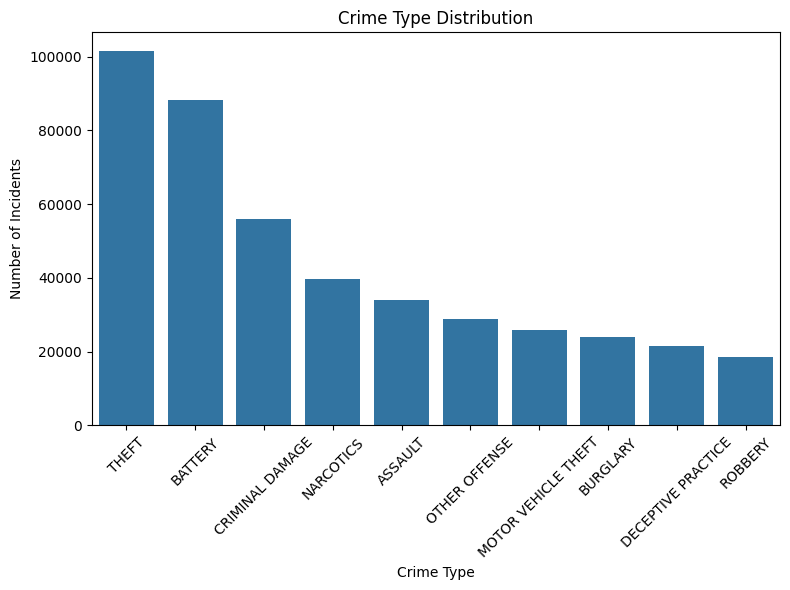

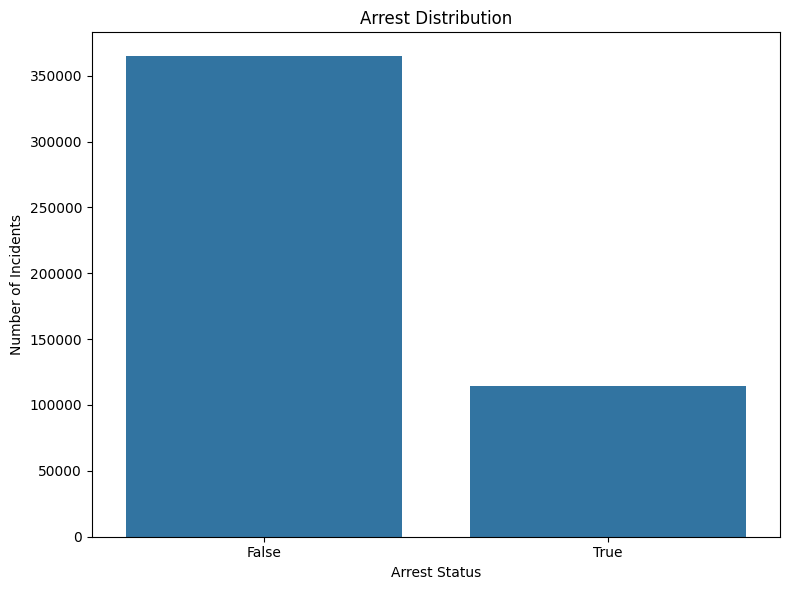

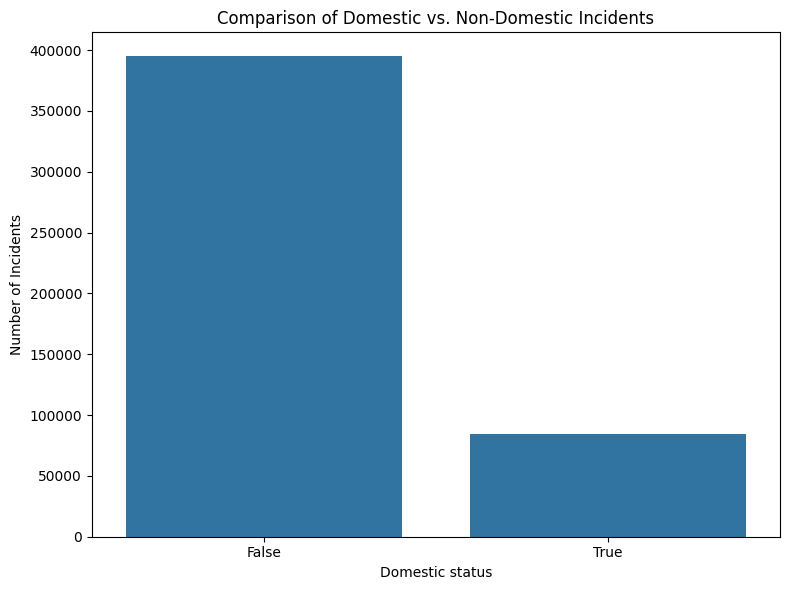

In [2]:
# crime type distribution(for 10 ten )
top_10_crimes = df["primary_type"].value_counts().head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_10_crimes.index, y=top_10_crimes.values)
plt.title("Crime Type Distribution")
plt.xlabel("Crime Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# arrest rate

arrest_rate = df['arrest'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=arrest_rate.index, y=arrest_rate.values)
plt.title("Arrest Distribution")
plt.xlabel("Arrest Status")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

# Domestic Crimes

domestic_crimes = df['domestic'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=domestic_crimes.index, y=domestic_crimes.values)
plt.title("Comparison of Domestic vs. Non-Domestic Incidents")
plt.xlabel("Domestic status")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()


TIME PATTERNS
1. Crimes by hours
2. Crimes by day of week
3. Crimes by Season
4. Crimes by weekend

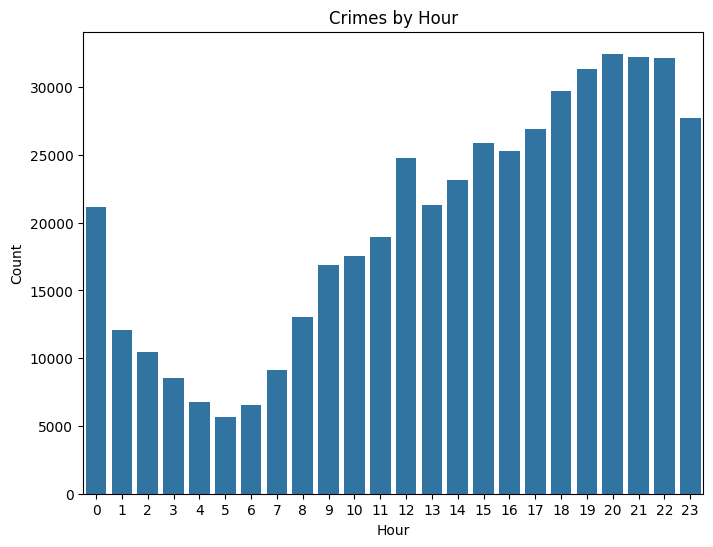

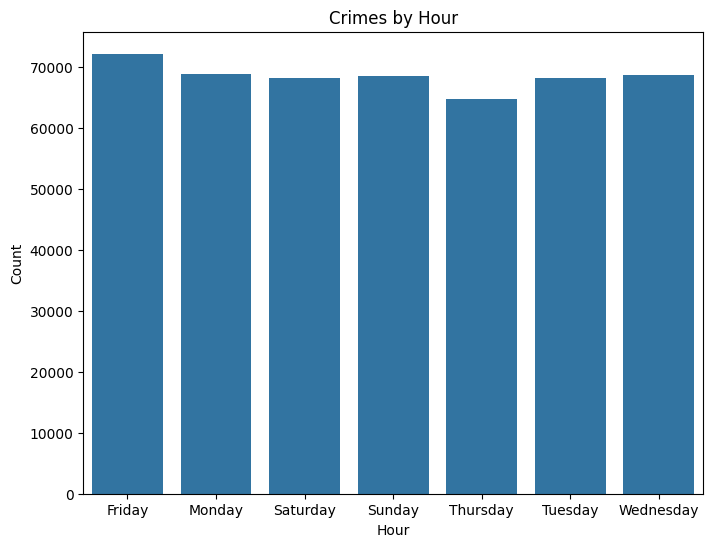

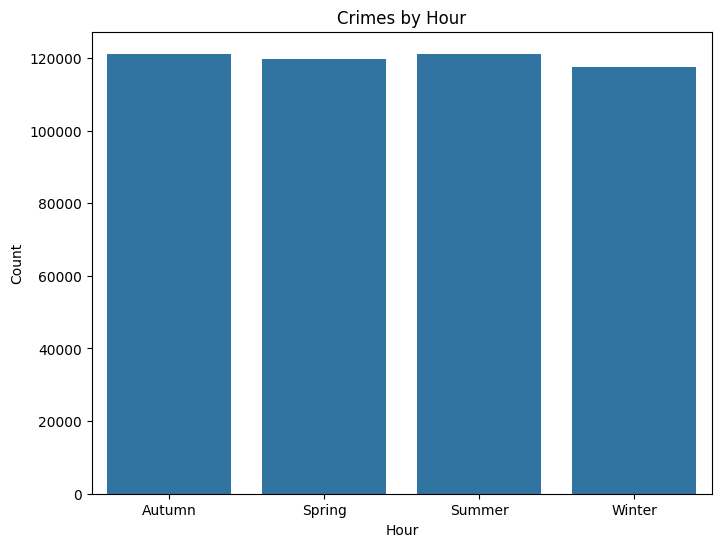

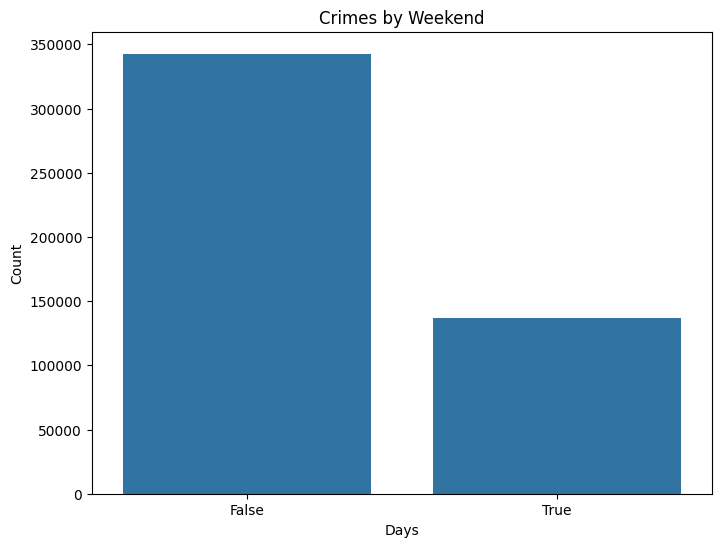

In [6]:
# Crimes by hours
crime_hour=df['hour'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
sns.barplot(x=crime_hour.index,y=crime_hour.values)
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# crimes by day of weeks
crime_day=df['day_name'].value_counts().sort_index()
plt.figure(figsize=(8, 6))
sns.barplot(x=crime_day.index,y=crime_day.values)
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# crimes by season

crime_season=df["season"].value_counts().sort_index()
plt.figure(figsize=(8, 6))
sns.barplot(x=crime_season.index,y=crime_season.values)
plt.title("Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

Weekend_crimes =df["Weekend_crimes"].value_counts().sort_index()
plt.figure(figsize=(8, 6))
sns.barplot(x=Weekend_crimes.index,y=Weekend_crimes.values)
plt.title("Crimes by Weekend")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

1. Crime Locations Scatter 
2. Crime Density
3. Crime by district


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\eda_chicago_crime.csv")

In [17]:
# This gives you min, max, and quartiles for both columns
print(df[['latitude', 'longitude']].describe())

            latitude      longitude
count  479440.000000  479440.000000
mean       41.842484     -87.670571
std         0.086623       0.058296
min        41.560467     -87.840826
25%        41.768228     -87.713056
50%        41.857494     -87.664908
75%        41.906736     -87.627877
max        42.022548     -87.524529


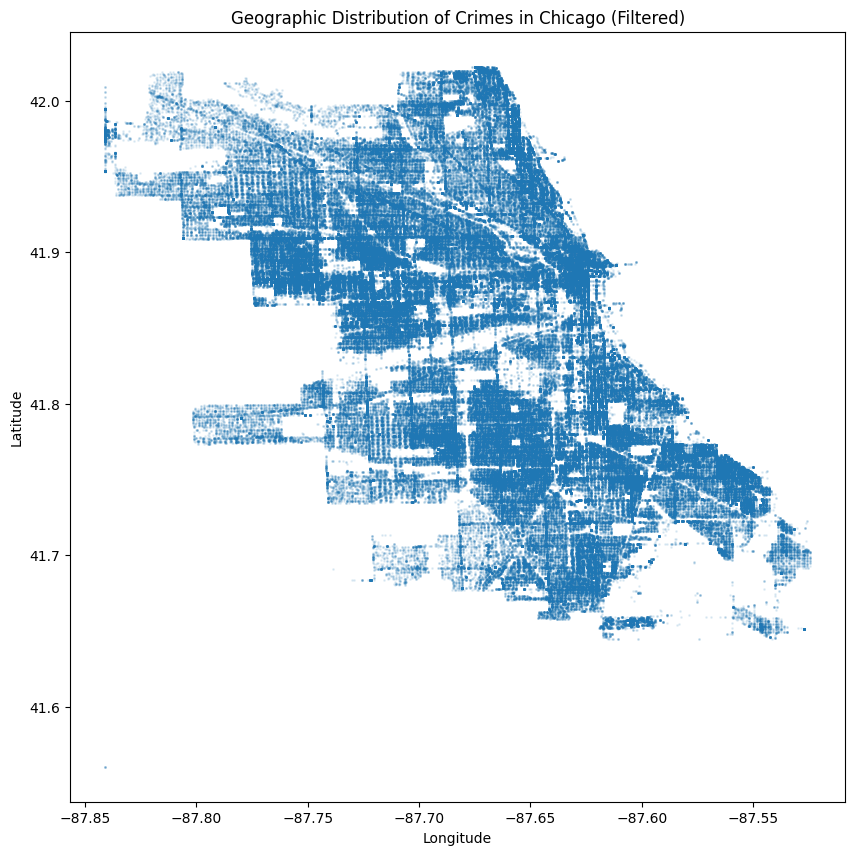

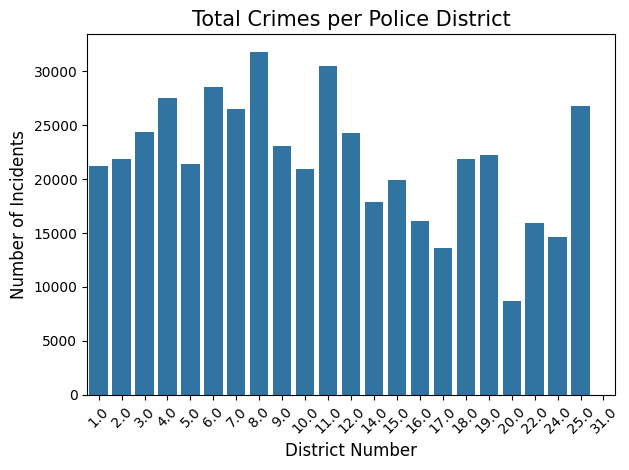

In [ ]:
# Crime Locations Scatter 

plt.figure(figsize=(10, 10))
plt.scatter(
    df["longitude"],
    df["latitude"], 
    s=1, 
    alpha=0.1 # Lower alpha helps see density in tight clusters
)

plt.title("Geographic Distribution of Crimes in Chicago (Filtered)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


crime_district = df["district"].value_counts().sort_index()

sns.barplot(x=crime_district.index, y=crime_district.values)
plt.title("Total Crimes per Police District", fontsize=15)
plt.xlabel("District Number", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [21]:
df.columns

Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location', 'hour', 'day_name', 'month', 'season',
       'Crime_Severity_Score', 'Weekend_crimes'],
      dtype='object')

In [22]:
numerical = df.select_dtypes(include=["int64", "float64"]).columns
categorical = df.select_dtypes(include=["object"]).columns
boolean = df.select_dtypes(include="bool").columns

pd.DataFrame({
    "Numerical": pd.Series(numerical),
    "Categorical": pd.Series(categorical),
    "Boolean": pd.Series(boolean)
})

,Numerical,Categorical,Boolean
0,id,case_number,arrest
1,beat,date,domestic
2,district,block,Weekend_crimes
3,ward,iucr,NaN
4,community_area,primary_type,NaN
5,x_coordinate,description,NaN
6,y_coordinate,location_description,NaN
7,year,fbi_code,NaN
8,latitude,updated_on,NaN
9,longitude,location,NaN


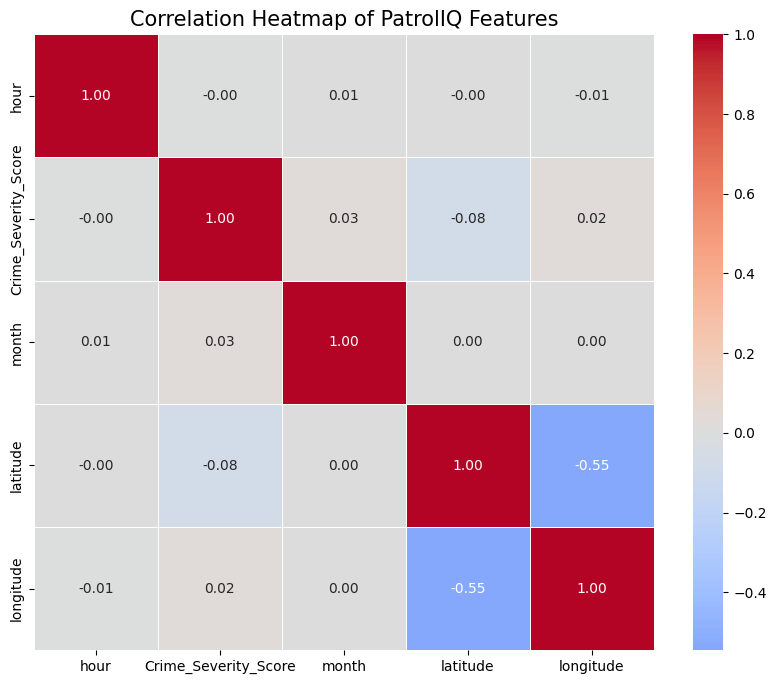

In [23]:
corr_df = df[["hour", "Crime_Severity_Score", "month", "latitude", "longitude"]].copy()
corr_matrix = corr_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,      # Shows the correlation numbers
    fmt=".2f",       # Rounds to 2 decimal places
    cmap="coolwarm", # Blue = Negative, Red = Positive correlation
    linewidths=0.5,
    center=0         # Ensures 0 is the neutral color
)
plt.title("Correlation Heatmap of PatrolIQ Features", fontsize=15)
plt.show()

In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\SAKTHI\Desktop\myproject\PatrolIQ\data\feature_data\feature_dataset.csv")

In [8]:
df.columns

Index(['id', 'case_number', 'date', 'block', 'iucr', 'primary_type',
       'description', 'location_description', 'arrest', 'domestic', 'beat',
       'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate',
       'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude',
       'location', 'hour', 'day_name', 'month', 'season', 'Weekend_crimes',
       'Crime_Severity_Score', 'lat_bin', 'lon_bin', 'district_cluster',
       'season_Autumn', 'season_Spring', 'season_Summer', 'season_Winter',
       'primary_type_ARSON', 'primary_type_ASSAULT', 'primary_type_BATTERY',
       'primary_type_BURGLARY',
       'primary_type_CONCEALED CARRY LICENSE VIOLATION',
       'primary_type_CRIM SEXUAL ASSAULT', 'primary_type_CRIMINAL DAMAGE',
       'primary_type_CRIMINAL SEXUAL ASSAULT',
       'primary_type_CRIMINAL TRESPASS', 'primary_type_DECEPTIVE PRACTICE',
       'primary_type_GAMBLING', 'primary_type_HOMICIDE',
       'primary_type_HUMAN TRAFFICKING',
       'primary_type_INTER